# Notebook for Evaluating the models

In [ ]:
# %pip install evaluate==0.4.0
# %pip install evaluate rouge-score
# %pip install bert-score
%pip install -U peft
!pip install bert-score

In [1]:
from unsloth import FastLanguageModel
# model most recently trained: "dsaedi/ESGF-Llama-3.1-8B-Instruct-V0.25"
# Base model: "unsloth/Meta-Llama-3.1-8B-Instruct"
fine_tuned_model, ft_tokenizer = FastLanguageModel.from_pretrained(
    model_name = "dsaedi/ESGF-Llama-3.1-8B-Instruct-V0.25",
    max_seq_length = 8192,
    dtype = None,
    load_in_4bit = True,
)

base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Meta-Llama-3.1-8B-Instruct",
    max_seq_length = 8192,
    dtype = None,
    load_in_4bit = True,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.3.9: Fast Llama patching. Transformers: 4.49.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 4. Max memory: 39.381 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.5.1+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.1.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2025.3.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


==((====))==  Unsloth 2025.3.9: Fast Llama patching. Transformers: 4.49.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 4. Max memory: 39.381 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.5.1+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.1.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [17]:
from unsloth.chat_templates import get_chat_template

def cleanOutput(text: str) -> str:
    """
    cleanOutput Takes generated output in llama 3.1 template 
    and extracts only the response removing all other tags

    :param1 text: input to be cleaned
    :return: cleaned string
    """
    text_split = text.split(
        "<|start_header_id|>assistant<|end_header_id|>")
    # Remove <|eot_id|> token at the end and return
    text_block = text_split[-1] # what ever is on the end
    output = text_block.split("<|eot_id|>")[0].strip()
    return output
  

def runModel(model, tokenizer, prompts):
    results = []
    tokenizer = get_chat_template(
        tokenizer,
        chat_template = "llama-3.1",
    )
    #FastLanguageModel.for_inference(model) # Enable native 2x faster inference
    FastLanguageModel.for_inference(model)
    
    # Then we loop through the prompts and tokenize and decode each result 
    # Then we clean up the outputs so that we just have the raw response to compare to without the template
    for prompt in prompts:
        print(prompt, '\n')
        messages = None
        messages = [
            {"role": "user", "content": prompt},
        ]
        inputs = tokenizer.apply_chat_template(
            messages,
            tokenize = True,
            add_generation_prompt = True, # Must add for generation
            return_tensors = "pt",
        ).to("cuda")
      
        # Fine-Tuned Model
        outputs =  model.generate(input_ids = inputs, max_new_tokens = 512, use_cache = True,
                                 temperature = 1.5, min_p = 0.1)
        raw_output = tokenizer.batch_decode(outputs)[0]
        cleaned = cleanOutput(raw_output)
        results.append(cleaned)
    return results

# We make a list of the prompts we are giving to the modle
prompts = [
    "List all the experiments ACCESS-CM2 offers using intake-esgf.",
    "Please explain histSST-1950HC as described within ESGF.",
    "Retrieve all models under ssp245, ssp585 scenarios for variable cLeaf with the help of intake-esgf.",
    "I'm trying to search for models that have data on variables tos, evspsbl using the intake-esgf library in python. Can you help?",
    "What can you tell me about the experiment piControl-withism?"  #example of question that RAG can now answer but would require further fine-tuning otherwise
]
# Call the function to run the model and give us a list of results
base_results = runModel(base_model,base_tokenizer, prompts)
ft_results = runModel(fine_tuned_model, ft_tokenizer, prompts)

#######################################################################################
# For text Streaming instead
'''
from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(input_ids = inputs, streamer = text_streamer, max_new_tokens = 256,
                   use_cache = True, temperature = 1.5, min_p = 0.1)
'''

List all the experiments ACCESS-CM2 offers using intake-esgf. 

Please explain histSST-1950HC as described within ESGF. 

Retrieve all models under ssp245, ssp585 scenarios for variable cLeaf with the help of intake-esgf. 

I'm trying to search for models that have data on variables tos, evspsbl using the intake-esgf library in python. Can you help? 

What can you tell me about the experiment piControl-withism? 

List all the experiments ACCESS-CM2 offers using intake-esgf. 

Please explain histSST-1950HC as described within ESGF. 

Retrieve all models under ssp245, ssp585 scenarios for variable cLeaf with the help of intake-esgf. 

I'm trying to search for models that have data on variables tos, evspsbl using the intake-esgf library in python. Can you help? 

What can you tell me about the experiment piControl-withism? 



'\nfrom transformers import TextStreamer\ntext_streamer = TextStreamer(tokenizer, skip_prompt = True)\n_ = model.generate(input_ids = inputs, streamer = text_streamer, max_new_tokens = 256,\n                   use_cache = True, temperature = 1.5, min_p = 0.1)\n'

In [21]:
# Visualize answers
for i, result in enumerate(base_results):
    print(f"{i + 1}: {result}")

print("#########################################################################################################")

for i, result in enumerate(ft_results):
    print(f"{i + 1}: {result}")


1: ACCESS-CM2 is a regional climate model that can be used for climate projections and impact assessments. It integrates into the CMIP framework and has the capability to do experiments under that umbrella, along with intake-esgf experiments as well. 

Here are some experiments that ACCESS-CM2 offers using intake-esgf:

1. **Hist2000**: A historical experiment for 2000-2004.
2. **Hist2000-2100**: A historical experiment for the 21st Century.
3. **Nat**: A natural experiment where greenhouse gases are at their pre-industrial values but with changes in anthropogenic aerosols, and land-use land cover and sea-ice and so forth.
2: Unfortunately I was unable to verify the histSST-1950HC dataset mentioned within the Earth System Grid Federation (ESGF) before the current response. The dataset description and further information provided would have given you better insight but with what I could find:

histSST-1950HC is a dataset provided within the ESGF. This dataset appears to be an ocean mode

In [19]:
#################################################
## BERTScore
#################################################

from bert_score import BERTScorer
    
# We have base_results and ft_results from above
# A list of expected outputs to compare against the results we just generated
# Order matters here --> in the same order we prompted the models
candidate = [
    "Alright! Here is how we can generate a list of all the experiments ACCESS-CM2 offers using python and intake-esgf:\n```python\nfrom intake_esgf import ESGFCatalog\n\n# initialize the catalog\ncat = ESGFCatalog()\n\n# specify the source ID to search for\nsources = [\"ACCESS-CM2\"]\n\nsearch_results = cat.search(\n    source_id=sources\n)\n\n# get a list of unique experiments\nexperiments = sorted(search_results.df[\"experiment_id\"].unique())\n\n# print out our results\nprint(f\"ACCESS-CM2 Experiements({len(experiments)} results):\")\n\nfor i, experiment in enumerate(experiments):\n    print(f\"{i+1}. {experiment}\")\n```\n",
    "Sure! Here is how the experiment histSST-piAer is described within ESGF: historical SSTs and historical forcing, but with pre-industrial aerosol emissions.",
    "Of course! Here is how we can find what models support cLeaf across ssp245, ssp585 scenarios using intake-esgf in python:\n```python\nfrom intake_esgf import ESGFCatalog\n\n# initialize the catalog\ncat = ESGFCatalog()\n\n# specify the scenarios and variables to search for\nexperiments = [\"ssp245\", \"ssp585\"]\nvariables = [\"pr\", \"tas\"]\n\nsearch_results = cat.search(\n    experiment_id=experiments,\n    variable_id=variables\n)\n\n# get a list of unique models\nmodels = sorted(search_results.df[\"source_id\"].unique())\n\n# print out our results\nprint(f\"Models({len(models)} results):\")\nfor i, model in enumerate(models):\n    print(f\"{i+1}. {model}\")\n```\n",
    "Sure! Here is how we can search for models that have data on variables tas, cSoil using the intake-esgf library in python:\n```python\nfrom intake_esgf import ESGFCatalog\n\n# initialize the catalog\ncat = ESGFCatalog()\n\n# specify variables to search for\nvariables = [\"tos\", \"evspsbl\"]\n\n# search the catalog for models with the specified variable\nsearch_results = cat.search(\n    variable_id=variables\n)\n\n# get a list of unique models\nmodels = sorted(search_results.df[\"source_id\"].unique())\n\n# print out our results\nprint(f\"Models({len(models)} results):\")\nfor i, model in enumerate(models):\n    print(f\"{i+1}. {model}\")\n```\n",
    "Here is what I know about piControl-withism. It is an experiment ID representing an experiemnt with the following description: preindustrial control with interactive ice sheet.",
]

# BERTScorer
scorer = BERTScorer(model_type='bert-base-uncased')
# P = precision, R = Recall, F1 = Harmonic avg. of both
# reference and candidate must be in a list
P_B, R_B, F1_B = scorer.score(base_results, candidate)
print(f"Overall Base-Model BERTScore Precision: {P_B.mean():.4f}, Recall: {R_B.mean():.4f}, F1: {F1_B.mean():.4f}")

P_FT, R_FT, F1_FT = scorer.score(ft_results, candidate)
print(f"Overall Fine-Tuned Model BERTScore Precision: {P_FT.mean():.4f}, Recall: {R_FT.mean():.4f}, F1: {F1_FT.mean():.4f}")
print()

for i, (p, r, f1) in enumerate(zip(P_B, R_B, F1_B)):
    print(f"Base_Model [Prompt {i+1}]")
    print(f"Precision: {p.item():.4f}, Recall: {r.item():.4f}, F1: {f1.item():.4f}")
print()
for i, (p, r, f1) in enumerate(zip(P_FT, R_FT, F1_FT)):
    print(f"Fine-Tuned Model [Prompt {i+1}]")
    print(f"Precision: {p.item():.4f}, Recall: {r.item():.4f}, F1: {f1.item():.4f}")
print()

# Rouge scorer
# scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
# scores = scorer.score(reference, candidate)
# print("ROUGE-L F1:", scores["rougeL"].fmeasure)

Overall Base-Model BERTScore Precision: 0.5074, Recall: 0.5983, F1: 0.5470
Overall Fine-Tuned Model BERTScore Precision: 0.9257, Recall: 0.9095, F1: 0.9175

Base_Model [Prompt 1]
Precision: 0.4969, Recall: 0.4693, F1: 0.4827
Base_Model [Prompt 2]
Precision: 0.4207, Recall: 0.5674, F1: 0.4831
Base_Model [Prompt 3]
Precision: 0.6279, Recall: 0.7192, F1: 0.6705
Base_Model [Prompt 4]
Precision: 0.5765, Recall: 0.6746, F1: 0.6217
Base_Model [Prompt 5]
Precision: 0.4150, Recall: 0.5611, F1: 0.4771

Fine-Tuned Model [Prompt 1]
Precision: 0.9521, Recall: 0.9386, F1: 0.9453
Fine-Tuned Model [Prompt 2]
Precision: 0.8865, Recall: 0.8642, F1: 0.8752
Fine-Tuned Model [Prompt 3]
Precision: 0.9339, Recall: 0.9156, F1: 0.9247
Fine-Tuned Model [Prompt 4]
Precision: 0.9262, Recall: 0.9017, F1: 0.9138
Fine-Tuned Model [Prompt 5]
Precision: 0.9298, Recall: 0.9271, F1: 0.9284



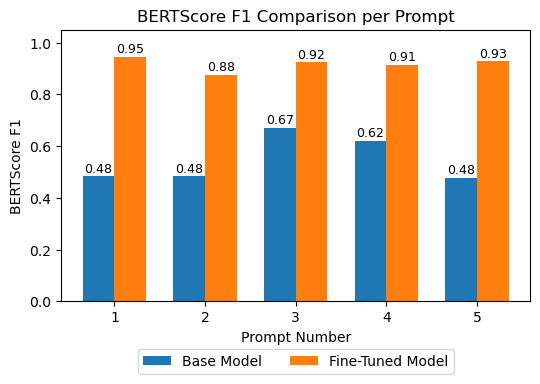

In [20]:
###################################################
## Graphing the Resuls of the BERTScore findings ##
###################################################
import matplotlib.pyplot as plt
import numpy as np

# Convert Torch sensors to regular lists and floats
base_f1 = [x.item() for x in F1_B]
ft_f1 = [x.item() for x in F1_FT]

x = np.arange(len(base_f1))
width = 0.35

fig, ax = plt.subplots(figsize=(5.5, 4))
bars1 = ax.bar(x - width/2, base_f1, width, label='Base Model')
bars2 = ax.bar(x + width/2, ft_f1, width, label='Fine-Tuned Model')

ax.set_xlabel('Prompt Number', fontsize=10)
ax.set_ylabel('BERTScore F1', fontsize=10)
ax.set_title('BERTScore F1 Comparison per Prompt', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f"{i+1}" for i in x], fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10,loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

# Annotate bars with values
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.show()